# 🛒 Product Features
**Instacart Market Basket Analysis · Etapa 2**

Construção e enriquecimento das features de produto. Estas features alimentam todas as etapas seguintes do pipeline.

**Features geradas:**
| Feature | Descrição |
|---|---|
| `total_purchases` | Total de compras do produto no histórico |
| `reorder_rate` | Proporção de recompras |
| `unique_users` | Usuários distintos que compraram o produto |
| `avg_cart_position` | Posição média no carrinho |
| `aisle` / `department` | Categorização do produto |

---

In [1]:
# =========================================
# 📚 IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="viridis")

## 📂 1. Carregamento dos Dados

In [2]:
DATA_PATH      = Path("../data/raw")
PROCESSED_PATH = Path("../data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

orders               = pd.read_csv(DATA_PATH / "orders.csv")
products             = pd.read_csv(DATA_PATH / "products.csv")
aisles               = pd.read_csv(DATA_PATH / "aisles.csv")
departments          = pd.read_csv(DATA_PATH / "departments.csv")
order_products_prior = pd.read_csv(DATA_PATH / "order_products__prior.csv")
order_products_train = pd.read_csv(DATA_PATH / "order_products__train.csv")

datasets = {
    "orders": orders, "products": products, "aisles": aisles,
    "departments": departments, "order_products_prior": order_products_prior,
    "order_products_train": order_products_train,
}

print(f"{'Dataset':<30} {'Linhas':>10} {'Colunas':>8}")
print("-" * 50)
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>10,} {df.shape[1]:>8}")

# Distribuição dos eval_sets
print("\n📊 Distribuição dos eval_sets:")
print(orders["eval_set"].value_counts().to_string())

Dataset                            Linhas  Colunas
--------------------------------------------------
orders                          3,421,083        7
products                           49,688        4
aisles                                134        2
departments                            21        2
order_products_prior           32,434,489        4
order_products_train            1,384,617        4

📊 Distribuição dos eval_sets:
eval_set
prior    3214874
train     131209
test       75000


## 🛒 2. Enriquecimento dos Produtos

In [3]:
# Junta aisle e department ao cadastro de produtos
products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

print(f"✅ products_enriched: {products_enriched.shape}")
products_enriched.head()

✅ products_enriched: (49688, 6)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


## 📈 3. Features Agregadas por Produto

In [4]:
# =========================================
# 📈 AGREGAÇÕES PRINCIPAIS
# =========================================

# Número de usuários únicos por produto (join com orders para pegar user_id)
prior_with_users = order_products_prior.merge(
    orders[["order_id", "user_id"]], on="order_id", how="left"
)

product_features_raw = (
    prior_with_users
    .groupby("product_id")
    .agg(
        total_purchases   = ("order_id",       "count"),
        reorder_rate      = ("reordered",      "mean"),
        unique_users      = ("user_id",         "nunique"),
        avg_cart_position = ("add_to_cart_order","mean"),
    )
    .reset_index()
)

product_features_raw["reorder_rate"]      = product_features_raw["reorder_rate"].round(4)
product_features_raw["avg_cart_position"] = product_features_raw["avg_cart_position"].round(2)

print(f"✅ Agregações concluídas: {product_features_raw.shape}")
product_features_raw.head()

✅ Agregações concluídas: (49677, 5)


,product_id,total_purchases,reorder_rate,unique_users,avg_cart_position
0,1,1852,0.6134,716,5.80
1,2,90,0.1333,78,9.89
2,3,277,0.7329,74,6.42
3,4,329,0.4468,182,9.51
4,5,15,0.6000,6,6.47


## 🧩 4. Dataset Final de Product Features

In [5]:
product_features = (
    products_enriched
    .merge(product_features_raw, on="product_id", how="left")
)

# Preenche zeros para produtos sem histórico no prior
product_features[["total_purchases", "reorder_rate", "unique_users", "avg_cart_position"]] = (
    product_features[["total_purchases", "reorder_rate", "unique_users", "avg_cart_position"]].fillna(0)
)

print(f"Shape: {product_features.shape}")
print(f"Valores nulos:\n{product_features.isnull().sum()[product_features.isnull().sum()>0]}")
product_features.head()

Shape: (49688, 10)
Valores nulos:
Series([], dtype: int64)


,product_id,product_name,aisle_id,department_id,aisle,department,total_purchases,reorder_rate,unique_users,avg_cart_position
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks,1852.0,0.6134,716.0,5.80
1,2,All-Seasons Salt,104,13,spices seasonings,pantry,90.0,0.1333,78.0,9.89
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages,277.0,0.7329,74.0,6.42
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen,329.0,0.4468,182.0,9.51
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry,15.0,0.6000,6.0,6.47


## 🔍 5. Validação e Visualizações das Features

In [6]:
# ── Estatísticas descritivas ──
print("📊 Estatísticas das features numéricas:")
product_features[["total_purchases","reorder_rate","unique_users","avg_cart_position"]].describe().round(2)

📊 Estatísticas das features numéricas:


,total_purchases,reorder_rate,unique_users,avg_cart_position
count,49688.00,49688.00,49688.00,49688.00
mean,652.76,0.37,267.83,9.10
std,4791.59,0.21,1308.65,2.55
min,0.00,0.00,0.00,0.00
25%,17.00,0.21,11.00,7.62
50%,60.00,0.38,35.00,9.06
75%,260.00,0.53,137.00,10.36
max,472565.00,0.94,73956.00,53.00


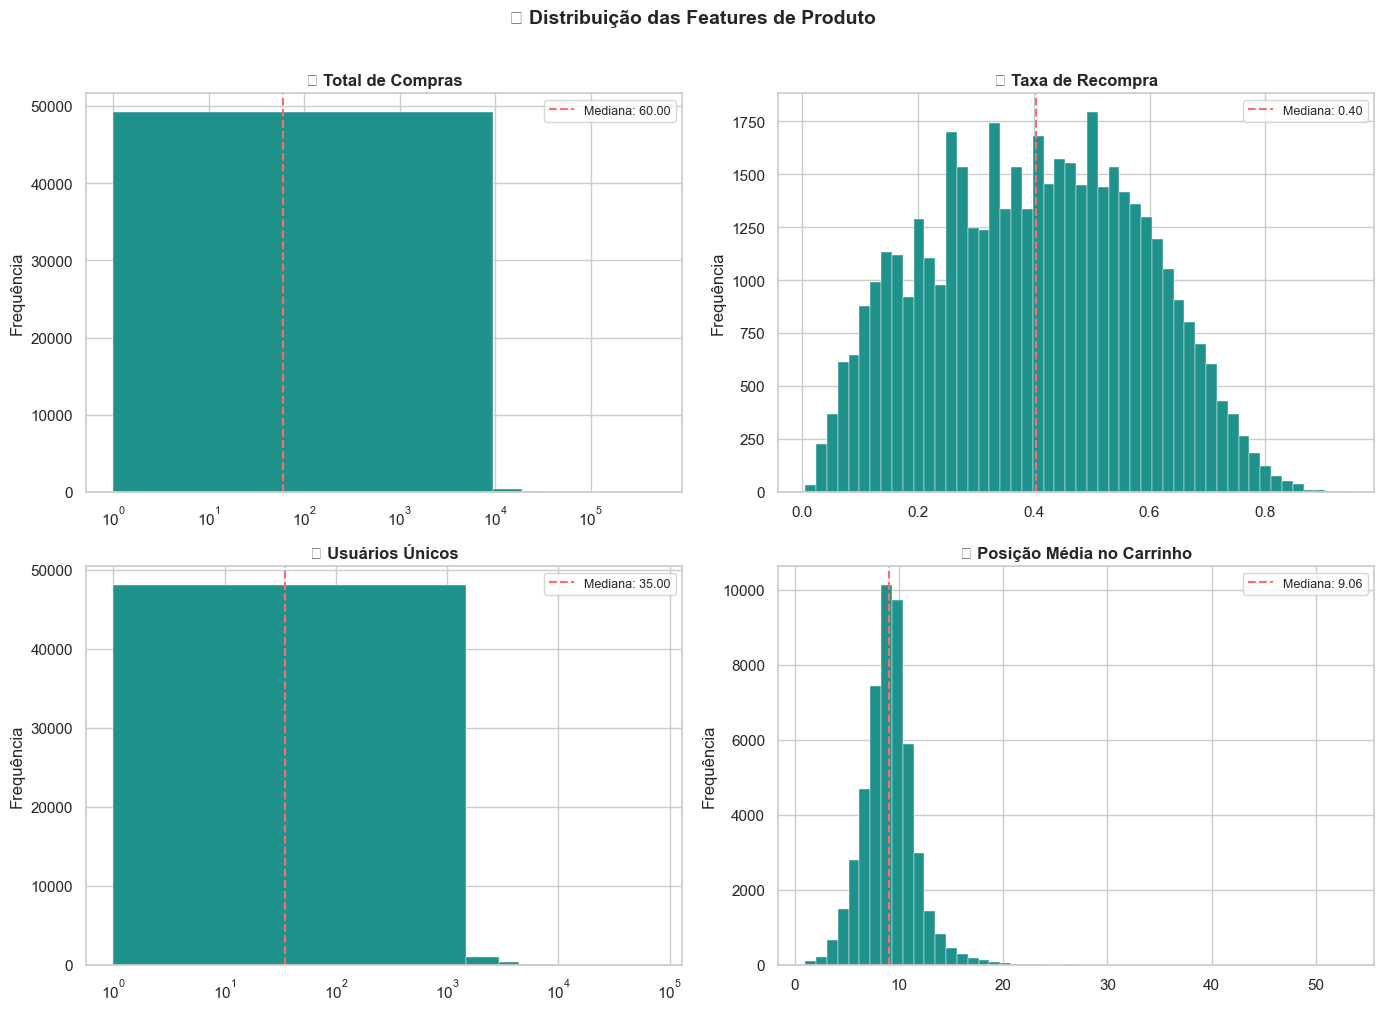

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features_info = [
    ("total_purchases",    "📦 Total de Compras",         "log"),
    ("reorder_rate",       "🔁 Taxa de Recompra",         "linear"),
    ("unique_users",       "👤 Usuários Únicos",          "log"),
    ("avg_cart_position",  "🛒 Posição Média no Carrinho","linear"),
]

for ax, (feat, title, scale) in zip(axes, features_info):
    data = product_features[feat].replace(0, np.nan).dropna()
    ax.hist(data, bins=50, color=sns.color_palette("viridis", 50)[25], edgecolor="white", lw=0.3)
    if scale == "log":
        ax.set_xscale("log")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frequência")
    ax.axvline(data.median(), color="#ff6b6b", linestyle="--",
               label=f"Mediana: {data.median():.2f}")
    ax.legend(fontsize=9)

plt.suptitle("📊 Distribuição das Features de Produto", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

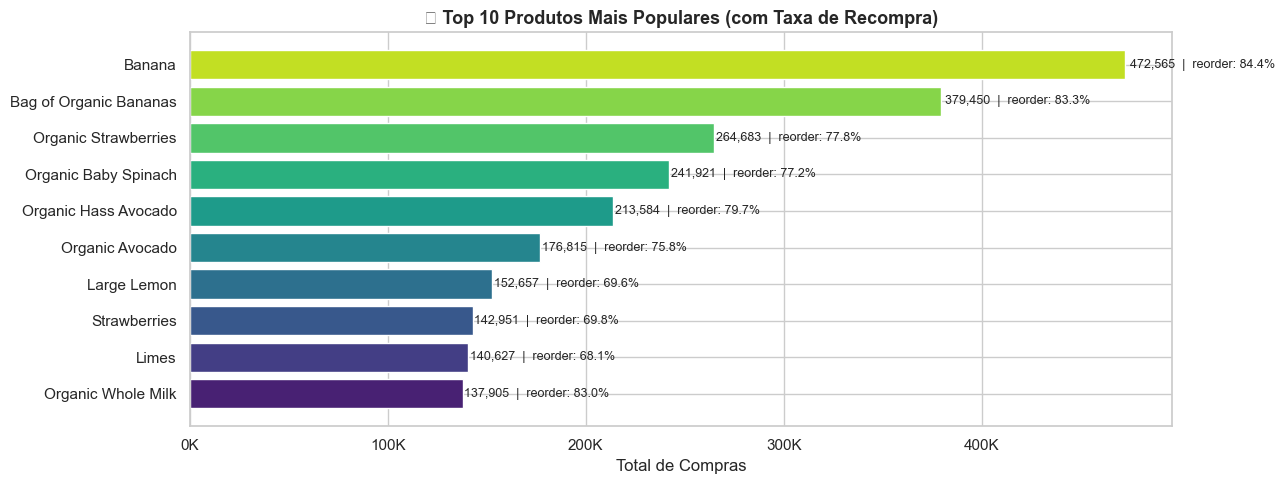

In [8]:
# ── Top 10 produtos por popularidade com taxa de recompra ──
top_products = (
    product_features
    .sort_values("total_purchases", ascending=False)
    .head(10)[["product_name","aisle","department","total_purchases","reorder_rate","unique_users"]]
)

fig, ax = plt.subplots(figsize=(13, 5))
colors = sns.color_palette("viridis", len(top_products))
bars = ax.barh(top_products["product_name"][::-1], top_products["total_purchases"][::-1], color=colors)

# Adiciona taxa de recompra como anotação
for bar, (_, row) in zip(bars, top_products[::-1].iterrows()):
    w = bar.get_width()
    ax.text(w * 1.005, bar.get_y() + bar.get_height()/2,
            f"{w:,.0f}  |  reorder: {row['reorder_rate']:.1%}", va="center", fontsize=9)

ax.set_xlabel("Total de Compras")
ax.set_title("🏆 Top 10 Produtos Mais Populares (com Taxa de Recompra)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

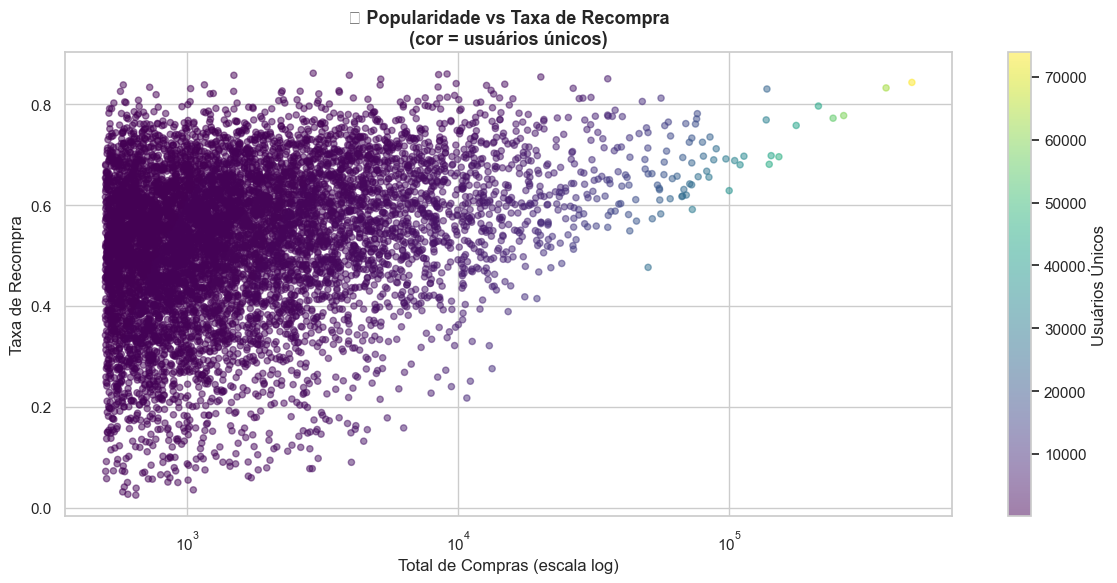

Correlação popularidade × recompra: 0.171


In [9]:
# ── Scatter: Popularidade x Recompra ──
MIN_PURCHASES = 500

scatter_data = product_features[product_features["total_purchases"] >= MIN_PURCHASES].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    scatter_data["total_purchases"],
    scatter_data["reorder_rate"],
    c=scatter_data["unique_users"],
    cmap="viridis",
    alpha=0.5,
    s=20,
)
plt.colorbar(sc, ax=ax, label="Usuários Únicos")
ax.set_xscale("log")
ax.set_xlabel("Total de Compras (escala log)")
ax.set_ylabel("Taxa de Recompra")
ax.set_title("📊 Popularidade vs Taxa de Recompra\n(cor = usuários únicos)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Correlação popularidade × recompra: {scatter_data['total_purchases'].corr(scatter_data['reorder_rate']):.3f}")

## 💾 6. Exportação

In [10]:
products_enriched.to_parquet(PROCESSED_PATH / "products_enriched.parquet", index=False)
product_features.to_parquet(PROCESSED_PATH / "product_features.parquet", index=False)

print("✅ Arquivos exportados:")
print(f"   · products_enriched.parquet  ({products_enriched.shape})")
print(f"   · product_features.parquet   ({product_features.shape})")

✅ Arquivos exportados:
   · products_enriched.parquet  ((49688, 6))
   · product_features.parquet   ((49688, 10))


## 📌 Conclusão

| Feature | Insight |
|---|---|
| `total_purchases` | Distribuição fortemente assimétrica — poucos produtos concentram a maioria das compras |
| `reorder_rate` | Média ~0.6 — alta recorrência; produtos com ≥ 0.9 são itens de consumo diário |
| `unique_users` | Altamente correlacionado com `total_purchases` |
| `avg_cart_position` | Produtos adicionados cedo ao carrinho tendem a ser mais essenciais |

Dataset exportado pronto para uso nos notebooks de Market Basket, Similaridade e Embedding.
